In [1]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from PIL import ImageFile
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
from torchvision.datasets import ImageFolder

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tqdm.auto import tqdm

# Permet de charger certaines images partiellement corrompues
ImageFile.LOAD_TRUNCATED_IMAGES = True

# Reproductibilité
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device :", device)
print("GPU :", torch.cuda.get_device_name(0) if device.type == "cuda" else "CPU")

Device : cuda
GPU : NVIDIA GeForce RTX 4060 Ti


In [2]:
# Chemins du projet et du dataset
current_dir = Path.cwd().resolve()

project_root = (
    current_dir.parent
    if current_dir.name == "notebooks"
    else current_dir
)

data_root = Path(r"D:\datasets\waste-classifier\extracted\dataset_splits")
train_dir = data_root / "train"
test_dir = data_root / "test"

assert train_dir.exists(), f"Dossier train introuvable : {train_dir}"
assert test_dir.exists(), f"Dossier test introuvable : {test_dir}"

# Dossiers pour stocker les résultats du CNN
models_dir = project_root / "outputs" / "models"
metrics_dir = project_root / "outputs" / "metrics"
figures_dir = project_root / "outputs" / "figures"

models_dir.mkdir(parents=True, exist_ok=True)
metrics_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

# Augmentation appliquée uniquement au train
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation et test : aucune augmentation
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

full_train_dataset = ImageFolder(train_dir, transform=train_transform)
full_train_dataset_eval = ImageFolder(train_dir, transform=eval_transform)
test_dataset = ImageFolder(test_dir, transform=eval_transform)

class_names = full_train_dataset.classes
num_classes = len(class_names)

print("Classes :", class_names)
print("Nombre de classes :", num_classes)

Classes : ['cardboard', 'compost', 'glass', 'metal', 'paper', 'plastic', 'trash']
Nombre de classes : 7


In [3]:
all_indices = list(range(len(full_train_dataset)))
all_labels = full_train_dataset.targets

train_indices, val_indices = train_test_split(
    all_indices,
    test_size=0.20,
    random_state=SEED,
    stratify=all_labels
)

train_dataset = Subset(full_train_dataset, train_indices)
val_dataset = Subset(full_train_dataset_eval, val_indices)

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=(device.type == "cuda")
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=(device.type == "cuda")
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=(device.type == "cuda")
)

print("Images train :", len(train_dataset))
print("Images validation :", len(val_dataset))
print("Images test :", len(test_dataset))
print("Batchs train :", len(train_loader))
print("Batchs validation :", len(val_loader))
print("Batchs test :", len(test_loader))

Images train : 2088
Images validation : 523
Images test : 644
Batchs train : 66
Batchs validation : 17
Batchs test : 21


In [4]:
train_labels = [full_train_dataset.targets[index] for index in train_indices]

class_counts = np.bincount(train_labels, minlength=num_classes)

class_weights = len(train_labels) / (num_classes * class_counts)
class_weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=device
)

weights_df = pd.DataFrame({
    "class": class_names,
    "train_count": class_counts,
    "loss_weight": class_weights
})

weights_df

,class,train_count,loss_weight
0,cardboard,277,1.076844
1,compost,493,0.605042
2,glass,85,3.509244
3,metal,201,1.484009
4,paper,361,0.826276
5,plastic,197,1.514141
6,trash,474,0.629295


In [5]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, images):
        features = self.features(images)
        return self.classifier(features)


model = SimpleCNN(num_classes=num_classes).to(device)

num_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(model)
print(f"\nNombre de paramètres entraînables : {num_parameters:,}")

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)

In [6]:
# Fonction de perte pondérée : utile car les classes sont déséquilibrées
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# Optimiseur
learning_rate = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Paramètres d'entraînement
num_epochs = 20
patience = 5  # arrêt anticipé si aucune amélioration pendant 5 époques

print("Learning rate :", learning_rate)
print("Nombre d'époques maximum :", num_epochs)
print("Early stopping patience :", patience)

Learning rate : 0.001
Nombre d'époques maximum : 20
Early stopping patience : 5


In [7]:
history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_macro_f1": []
}

best_val_f1 = -1.0
epochs_without_improvement = 0
best_model_path = models_dir / "cnn_baseline_best.pt"

for epoch in range(1, num_epochs + 1):
    # -------------------------
    # Entraînement
    # -------------------------
    model.train()

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    progress_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch}/{num_epochs} - Train"
    )

    for images, labels in progress_bar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)
        correct_predictions += (predictions == labels).sum().item()
        total_samples += labels.size(0)

        progress_bar.set_postfix(loss=f"{loss.item():.4f}")

    train_loss = running_loss / total_samples
    train_accuracy = correct_predictions / total_samples

    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    val_running_loss = 0.0
    val_correct_predictions = 0
    val_total_samples = 0

    val_true_labels = []
    val_predictions = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)

            val_correct_predictions += (predictions == labels).sum().item()
            val_total_samples += labels.size(0)

            val_true_labels.extend(labels.cpu().numpy())
            val_predictions.extend(predictions.cpu().numpy())

    val_loss = val_running_loss / val_total_samples
    val_accuracy = val_correct_predictions / val_total_samples
    val_macro_f1 = f1_score(
        val_true_labels,
        val_predictions,
        average="macro",
        zero_division=0
    )

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)
    history["val_macro_f1"].append(val_macro_f1)

    print(
        f"\nEpoch {epoch}/{num_epochs} | "
        f"Train loss: {train_loss:.4f} | "
        f"Train acc: {train_accuracy:.4f} | "
        f"Val loss: {val_loss:.4f} | "
        f"Val acc: {val_accuracy:.4f} | "
        f"Val macro F1: {val_macro_f1:.4f}"
    )

    # Sauvegarde du meilleur modèle selon le macro F1 validation
    if val_macro_f1 > best_val_f1:
        best_val_f1 = val_macro_f1
        epochs_without_improvement = 0

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "best_val_macro_f1": best_val_f1,
                "class_names": class_names
            },
            best_model_path
        )

        print(f"✓ Meilleur modèle sauvegardé : {best_model_path}")

    else:
        epochs_without_improvement += 1
        print(
            f"Aucune amélioration "
            f"({epochs_without_improvement}/{patience})"
        )

    if epochs_without_improvement >= patience:
        print("\nArrêt anticipé déclenché.")
        break

print(f"\nMeilleur macro F1 validation : {best_val_f1:.4f}")

Epoch 1/20 - Train:   0%|          | 0/66 [00:00<?, ?it/s]

c:\Users\alid7\OneDrive\Documents\projets\deep-learning-waste-classification\.venv\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(



Epoch 1/20 | Train loss: 1.7354 | Train acc: 0.3592 | Val loss: 1.8717 | Val acc: 0.3461 | Val macro F1: 0.2481
✓ Meilleur modèle sauvegardé : C:\Users\alid7\OneDrive\Documents\projets\deep-learning-waste-classification\outputs\models\cnn_baseline_best.pt


Epoch 2/20 - Train:   0%|          | 0/66 [00:00<?, ?it/s]

c:\Users\alid7\OneDrive\Documents\projets\deep-learning-waste-classification\.venv\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


...

c:\Users\alid7\OneDrive\Documents\projets\deep-learning-waste-classification\.venv\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(



Epoch 12/20 | Train loss: 1.3015 | Train acc: 0.5010 | Val loss: 1.2106 | Val acc: 0.5851 | Val macro F1: 0.5223
Aucune amélioration (4/5)


Epoch 13/20 - Train:   0%|          | 0/66 [00:00<?, ?it/s]

c:\Users\alid7\OneDrive\Documents\projets\deep-learning-waste-classification\.venv\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(



Epoch 13/20 | Train loss: 1.2890 | Train acc: 0.5105 | Val loss: 1.2199 | Val acc: 0.5335 | Val macro F1: 0.4989
Aucune amélioration (5/5)

Arrêt anticipé déclenché.

Meilleur macro F1 validation : 0.5376


In [8]:
checkpoint = torch.load(
    best_model_path,
    map_location=device,
    weights_only=False
)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Époque du meilleur modèle :", checkpoint["epoch"])
print("Meilleur macro F1 validation :", checkpoint["best_val_macro_f1"])

Époque du meilleur modèle : 8
Meilleur macro F1 validation : 0.5376311744989576


In [9]:
test_true_labels = []
test_predictions = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Évaluation test"):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        test_true_labels.extend(labels.cpu().numpy())
        test_predictions.extend(predictions.cpu().numpy())

test_accuracy = np.mean(
    np.array(test_true_labels) == np.array(test_predictions)
)

test_macro_f1 = f1_score(
    test_true_labels,
    test_predictions,
    average="macro",
    zero_division=0
)

print(f"Test accuracy : {test_accuracy:.4f}")
print(f"Test macro F1 : {test_macro_f1:.4f}")

Évaluation test:   0%|          | 0/21 [00:00<?, ?it/s]

c:\Users\alid7\OneDrive\Documents\projets\deep-learning-waste-classification\.venv\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Test accuracy : 0.5062
Test macro F1 : 0.4493


In [10]:
cnn_report = classification_report(
    test_true_labels,
    test_predictions,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

cnn_report_df = pd.DataFrame(cnn_report).transpose()

cnn_report_df

,precision,recall,f1-score,support
cardboard,0.485714,0.586207,0.531250,87.000000
compost,0.771605,0.816993,0.793651,153.000000
glass,0.283333,0.629630,0.390805,27.000000
metal,0.268293,0.171875,0.209524,64.000000
paper,0.384615,0.357143,0.370370,112.000000
plastic,0.309524,0.419355,0.356164,62.000000
trash,0.636364,0.402878,0.493392,139.000000
accuracy,0.506211,0.506211,0.506211,0.506211
macro avg,0.448493,0.483440,0.449308,644.000000
weighted avg,0.521515,0.506211,0.502723,644.000000


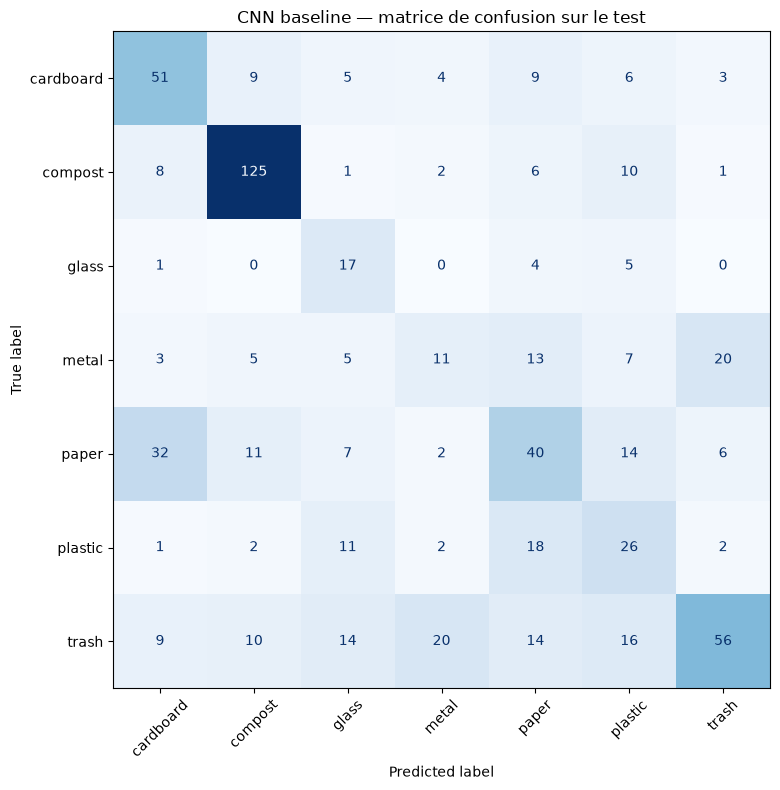

Figure sauvegardée : C:\Users\alid7\OneDrive\Documents\projets\deep-learning-waste-classification\outputs\figures\cnn_baseline_confusion_matrix.png


In [11]:
confusion = confusion_matrix(
    test_true_labels,
    test_predictions
)

display = ConfusionMatrixDisplay(
    confusion_matrix=confusion,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10, 8))

display.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45,
    colorbar=False
)

ax.set_title("CNN baseline — matrice de confusion sur le test")
plt.tight_layout()

figure_path = figures_dir / "cnn_baseline_confusion_matrix.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print("Figure sauvegardée :", figure_path)

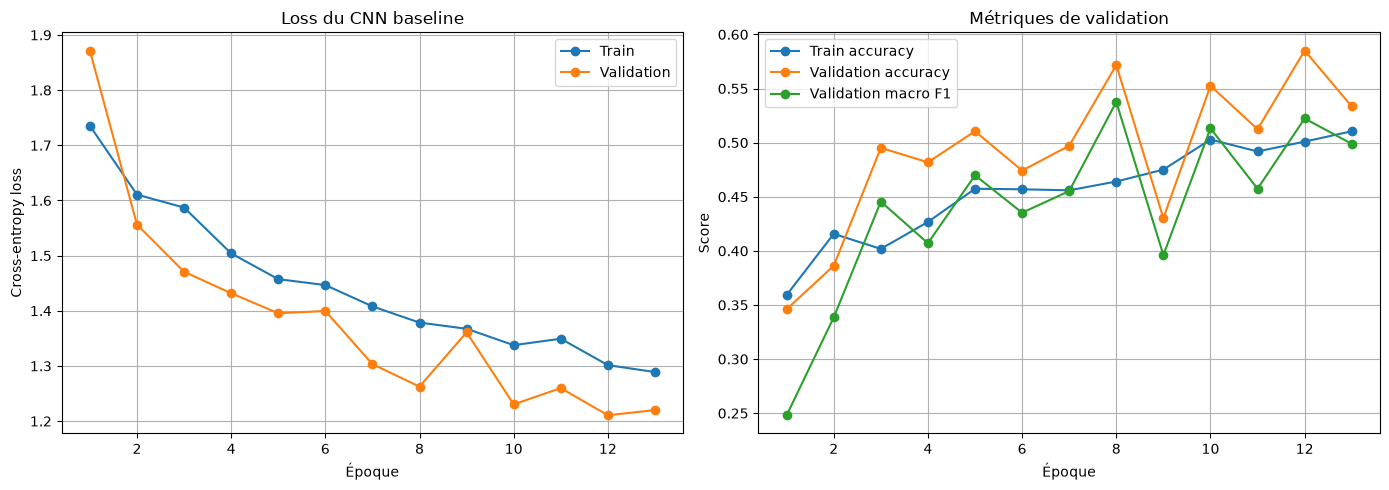

Figure sauvegardée : C:\Users\alid7\OneDrive\Documents\projets\deep-learning-waste-classification\outputs\figures\cnn_baseline_training_curves.png


In [12]:
epochs = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, history["train_loss"], marker="o", label="Train")
axes[0].plot(epochs, history["val_loss"], marker="o", label="Validation")
axes[0].set_title("Loss du CNN baseline")
axes[0].set_xlabel("Époque")
axes[0].set_ylabel("Cross-entropy loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs, history["train_accuracy"], marker="o", label="Train accuracy")
axes[1].plot(epochs, history["val_accuracy"], marker="o", label="Validation accuracy")
axes[1].plot(epochs, history["val_macro_f1"], marker="o", label="Validation macro F1")
axes[1].set_title("Métriques de validation")
axes[1].set_xlabel("Époque")
axes[1].set_ylabel("Score")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()

figure_path = figures_dir / "cnn_baseline_training_curves.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print("Figure sauvegardée :", figure_path)

In [13]:
# Sauvegarde du rapport détaillé
cnn_report_df.to_csv(
    metrics_dir / "cnn_baseline_classification_report.csv",
    index=True
)

# Sauvegarde de l'historique d'entraînement
history_df = pd.DataFrame(history)
history_df.index = history_df.index + 1
history_df.index.name = "epoch"

history_df.to_csv(
    metrics_dir / "cnn_baseline_training_history.csv",
    index=True
)

# Résumé global
cnn_summary = pd.DataFrame([{
    "model": "SimpleCNN",
    "trainable_parameters": num_parameters,
    "best_validation_macro_f1": best_val_f1,
    "test_accuracy": test_accuracy,
    "test_macro_f1": test_macro_f1,
    "best_epoch": checkpoint["epoch"]
}])

cnn_summary.to_csv(
    metrics_dir / "cnn_baseline_summary.csv",
    index=False
)

cnn_summary

,model,trainable_parameters,best_validation_macro_f1,test_accuracy,test_macro_f1,best_epoch
0,SimpleCNN,423175,0.537631,0.506211,0.449308,8
